# Complete Project Workflow

Import Libraries -> Load Dataset -> Understand Dataset -> Data Cleaning -> Exploratory Data Analysis -> Prepare Features and Target -> Train-Test Split -> Train Classification Model -> Evaluate Model -> Make Predictions

# Step 1 — Import Libraries

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Step 2 — Load Dataset

In [22]:
df = pd.read_csv("iris.csv")

In [23]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


# Step 3 — Understand the Dataset

In [24]:
df.shape

(150, 5)

In [25]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [27]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [28]:
df["species"].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

# Step 4 — Data Cleaning

In [29]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [30]:
df.duplicated().sum()

3

In [31]:
df.duplicated().sum()

3

In [32]:
df = df.drop_duplicates()

# Step 5 — Exploratory Data Analysis

## Species Distribution

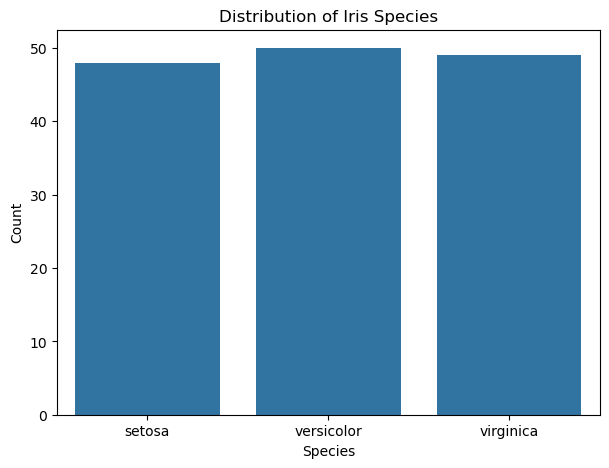

In [33]:
plt.figure(figsize=(7, 5))

sns.countplot(x="species", data=df)

plt.title("Distribution of Iris Species")
plt.xlabel("Species")
plt.ylabel("Count")

plt.show()


## Sepal Length Distribution

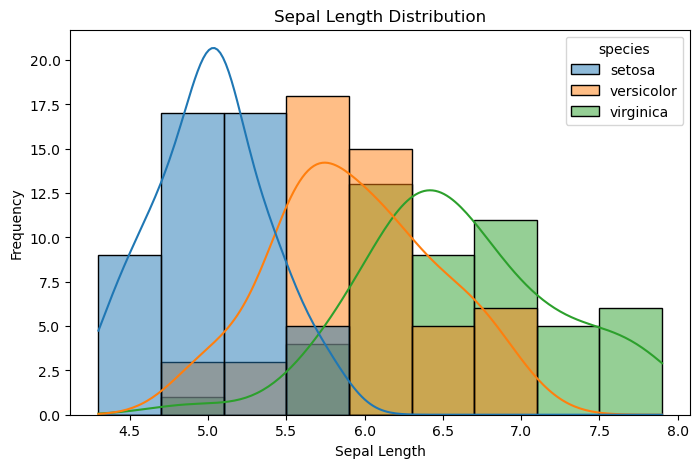

In [34]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="sepal_length",
    hue="species",
    kde=True
)

plt.title("Sepal Length Distribution")
plt.xlabel("Sepal Length")
plt.ylabel("Frequency")

plt.show()

## Sepal Width Distribution

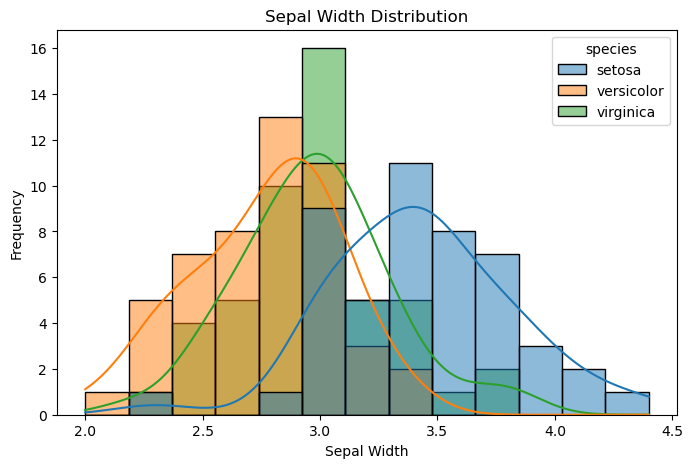

In [35]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="sepal_width",
    hue="species",
    kde=True
)

plt.title("Sepal Width Distribution")
plt.xlabel("Sepal Width")
plt.ylabel("Frequency")

plt.show()

## Petal Length Distribution

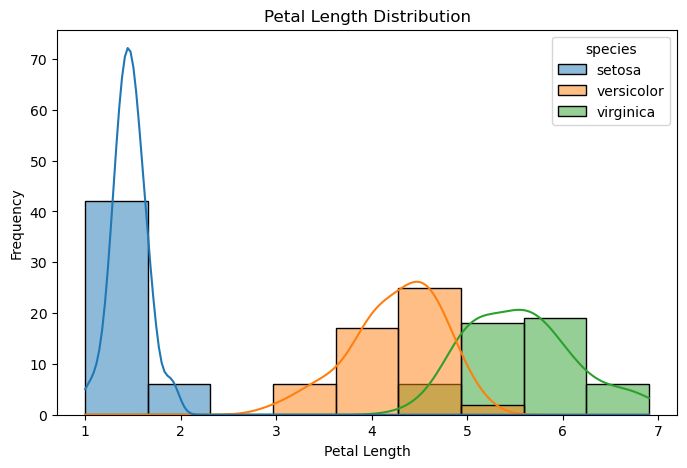

In [36]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="petal_length",
    hue="species",
    kde=True
)

plt.title("Petal Length Distribution")
plt.xlabel("Petal Length")
plt.ylabel("Frequency")

plt.show()

## Petal Width Distribution

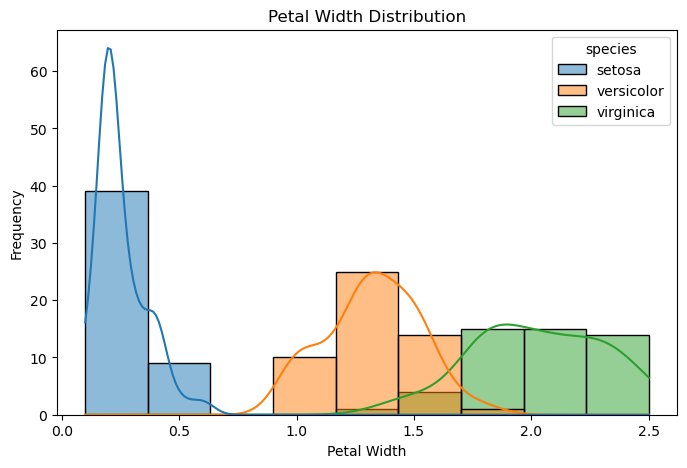

In [37]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="petal_width",
    hue="species",
    kde=True
)

plt.title("Petal Width Distribution")
plt.xlabel("Petal Width")
plt.ylabel("Frequency")

plt.show()

# STEP 7 — Scatter Plot Analysis

## Sepal Length vs Sepal Width

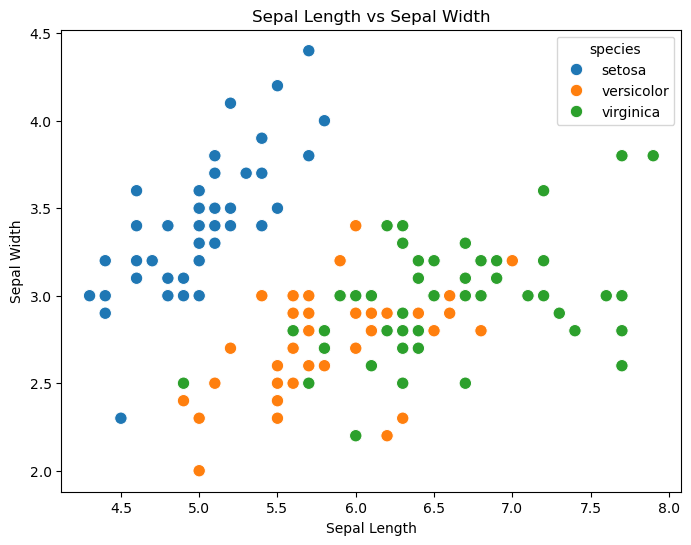

In [38]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="sepal_length",
    y="sepal_width",
    hue="species",
    s=80
)

plt.title("Sepal Length vs Sepal Width")
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")

plt.show()

## Petal Length vs Petal Width

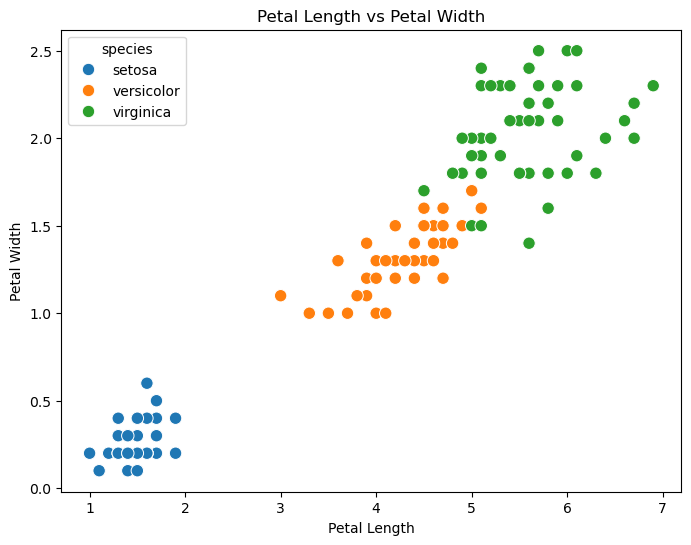

In [39]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="petal_length",
    y="petal_width",
    hue="species",
    s=80
)

plt.title("Petal Length vs Petal Width")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")

plt.show()

# STEP 8 — Pair Plot

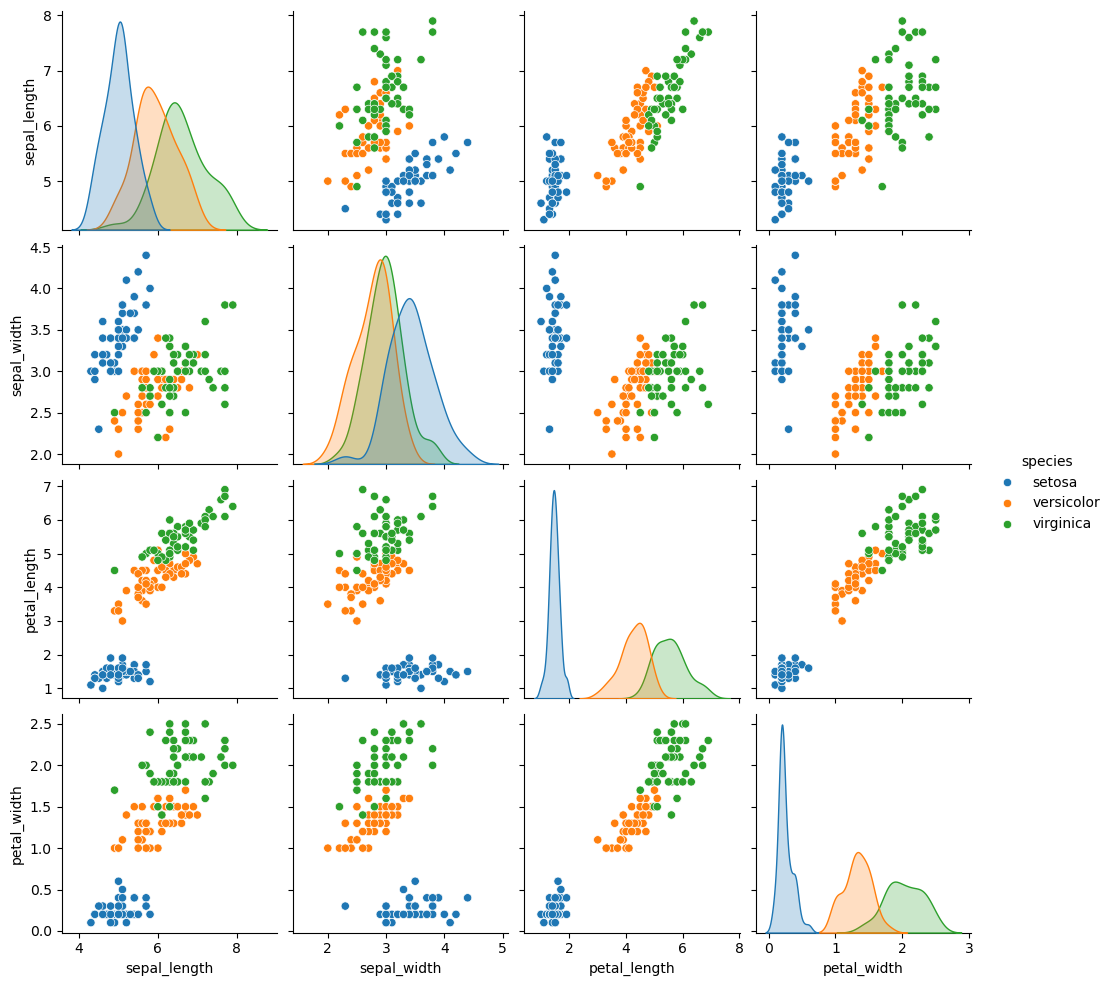

In [40]:
sns.pairplot(
    df,
    hue="species"
)

plt.show()

# STEP 9 — Correlation Analysis

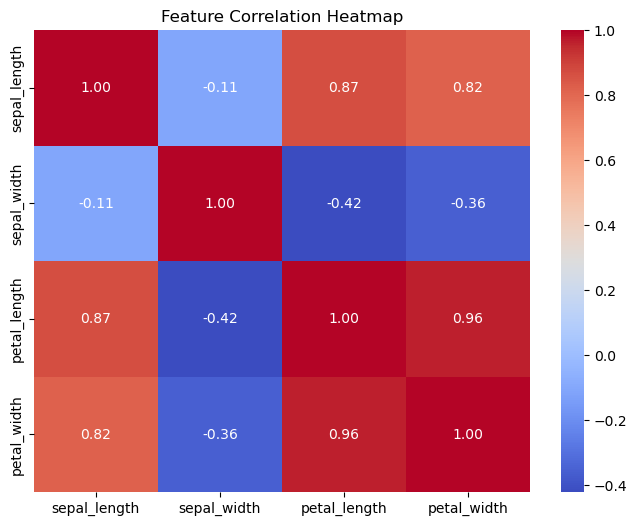

In [41]:
plt.figure(figsize=(8, 6))

correlation = df.drop("species", axis=1).corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")

plt.show()

# STEP 10 — Prepare Features and Target

In [42]:
X = df.drop("species", axis=1)

y = df["species"]

In [43]:
X.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [44]:
X.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


# STEP 11 — Train-Test Split

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [46]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (117, 4)
Testing data: (30, 4)


# STEP 12 — Feature Scaling

In [47]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [48]:
scaler.fit_transform(X_train)

array([[-0.04095301, -0.7435543 ,  0.17925687, -0.27993146],
       [-0.39155076, -0.96777042,  0.34976951, -0.01580258],
       [ 0.54337656, -0.29512207,  1.03182005,  0.77658405],
       [ 1.24457205,  0.15331017,  0.63395723,  0.38039073],
       [ 1.5951698 , -0.07090595,  1.14549514,  0.51245517],
       [ 1.5951698 ,  1.27439075,  1.31600777,  1.70103512],
       [ 0.66024248, -0.7435543 ,  0.86130741,  0.90864849],
       [-1.56020991, -1.64041877, -1.41219439, -1.20438253],
       [-0.97588033, -0.07090595, -1.24168175, -1.33644697],
       [ 2.4132312 ,  1.72282298,  1.48652041,  1.04071293],
       [ 2.17949937, -0.51933818,  1.65703304,  1.04071293],
       [-1.44334399,  0.37752628, -1.35535684, -1.33644697],
       [ 0.54337656, -0.51933818,  0.74763232,  0.38039073],
       [-0.85901442, -1.19198653, -0.44595612, -0.14786702],
       [-0.50841667,  1.9470391 , -1.41219439, -1.07231809],
       [ 1.01084022, -0.07090595,  0.80446987,  1.43690624],
       [-0.85901442,  1.

In [49]:
scaler.fit_transform(X_train)

array([[-0.04095301, -0.7435543 ,  0.17925687, -0.27993146],
       [-0.39155076, -0.96777042,  0.34976951, -0.01580258],
       [ 0.54337656, -0.29512207,  1.03182005,  0.77658405],
       [ 1.24457205,  0.15331017,  0.63395723,  0.38039073],
       [ 1.5951698 , -0.07090595,  1.14549514,  0.51245517],
       [ 1.5951698 ,  1.27439075,  1.31600777,  1.70103512],
       [ 0.66024248, -0.7435543 ,  0.86130741,  0.90864849],
       [-1.56020991, -1.64041877, -1.41219439, -1.20438253],
       [-0.97588033, -0.07090595, -1.24168175, -1.33644697],
       [ 2.4132312 ,  1.72282298,  1.48652041,  1.04071293],
       [ 2.17949937, -0.51933818,  1.65703304,  1.04071293],
       [-1.44334399,  0.37752628, -1.35535684, -1.33644697],
       [ 0.54337656, -0.51933818,  0.74763232,  0.38039073],
       [-0.85901442, -1.19198653, -0.44595612, -0.14786702],
       [-0.50841667,  1.9470391 , -1.41219439, -1.07231809],
       [ 1.01084022, -0.07090595,  0.80446987,  1.43690624],
       [-0.85901442,  1.

# STEP 13 — Train Machine Learning Model

In [51]:
model = LogisticRegression()

model.fit(X_train_scaled, y_train)

LogisticRegression()

# STEP 14 — Make Predictions

In [52]:
y_pred = model.predict(X_test_scaled)

In [53]:
y_pred = model.predict(X_test_scaled)

# STEP 15 — Evaluate Model

## Accuracy

In [54]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100)

Accuracy: 0.9333333333333333
Accuracy Percentage: 93.33333333333333


# STEP 16 — Classification Report

In [56]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



# STEP 17 — Confusion Matrix

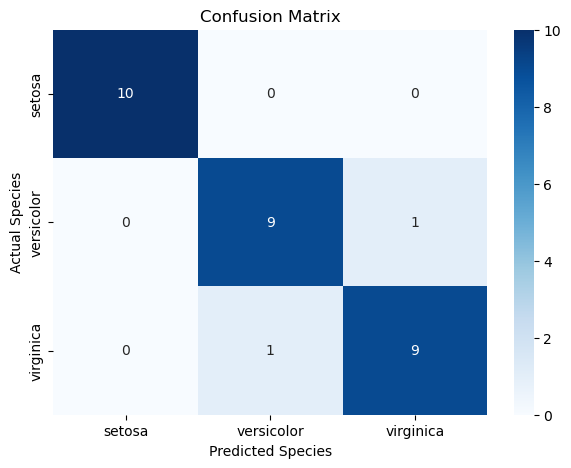

In [57]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")

plt.show()

# STEP 18 — Compare Actual vs Predicted

In [59]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,versicolor,versicolor
1,versicolor,versicolor
2,virginica,virginica
3,setosa,setosa
4,virginica,virginica
5,versicolor,virginica
6,versicolor,versicolor
7,setosa,setosa
8,virginica,virginica
9,virginica,virginica


# STEP 19 — Test a New Flower

In [60]:
new_flower = pd.DataFrame({
    "sepal_length": [5.1],
    "sepal_width": [3.5],
    "petal_length": [1.4],
    "petal_width": [0.2]
})

In [62]:
new_flower_scaled = scaler.transform(new_flower)

In [63]:
prediction = model.predict(new_flower_scaled)

print("Predicted Species:", prediction[0])

Predicted Species: setosa


# STEP 20 — Try Another Flower

In [64]:
new_flower = pd.DataFrame({
    "sepal_length": [6.7],
    "sepal_width": [3.0],
    "petal_length": [5.2],
    "petal_width": [2.3]
})

new_flower_scaled = scaler.transform(new_flower)

prediction = model.predict(new_flower_scaled)

print("Predicted Species:", prediction[0])

Predicted Species: virginica


# STEP 21 — Prediction Probability

In [65]:
probabilities = model.predict_proba(new_flower_scaled)

for species, probability in zip(model.classes_, probabilities[0]):
    print(species, ":", round(probability * 100, 2), "%")

setosa : 0.01 %
versicolor : 4.5 %
virginica : 95.49 %
